Used only past 24 h - Multivariative LSTM

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from lightgbm import LGBMRegressor

In [2]:
# Load dataset
df = pd.read_csv("weather_15min_interpolated_load_domestic.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort by time (VERY IMPORTANT)
df = df.sort_values("timestamp").reset_index(drop=True)

df.head()

,timestamp,temperature_C,humidity_percent,cloud_cover_percent,solar_irradiance_Wm2,wind_speed_ms,load_normalize,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,load_normalize.1
0,2025-06-10 00:00:00,25.600,94.00,100.0,0.0,6.4,0.201075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.837,peak load,0.9726
1,2025-06-10 00:15:00,25.675,94.25,100.0,0.0,6.4,0.331693,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6044
2,2025-06-10 00:30:00,25.750,94.50,100.0,0.0,6.4,0.168803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8165
3,2025-06-10 00:45:00,25.825,94.75,100.0,0.0,6.4,0.200331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9690
4,2025-06-10 01:00:00,25.900,95.00,100.0,0.0,6.4,0.218110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0550


In [4]:
df.tail()

,timestamp,temperature_C,humidity_percent,cloud_cover_percent,solar_irradiance_Wm2,wind_speed_ms,load_normalize,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,load_normalize.1
2972,2025-07-10 23:00:00,27.50,88.00,99.00,0.0,13.60,0.324147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.5679
2973,2025-07-10 23:15:00,27.45,88.25,98.75,0.0,14.15,0.333223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6118
2974,2025-07-10 23:30:00,27.40,88.50,98.50,0.0,14.70,0.337544,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6327
2975,2025-07-10 23:45:00,27.35,88.75,98.25,0.0,15.25,0.300682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.4544
2976,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2977 entries, 0 to 2976
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             2976 non-null   datetime64[ns]
 1   temperature_C         2976 non-null   float64       
 2   humidity_percent      2976 non-null   float64       
 3   cloud_cover_percent   2976 non-null   float64       
 4   solar_irradiance_Wm2  2976 non-null   float64       
 5   wind_speed_ms         2976 non-null   float64       
 6   load_normalize        2976 non-null   float64       
 7   Unnamed: 7            0 non-null      float64       
 8   Unnamed: 8            0 non-null      float64       
 9   Unnamed: 9            0 non-null      float64       
 10  Unnamed: 10           0 non-null      float64       
 11  Unnamed: 11           0 non-null      float64       
 12  Unnamed: 12           0 non-null      float64       
 13  Unnamed: 13       

In [5]:
#  Interpolate missing values (linear for time series)
df = df.interpolate(method="linear")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2977 entries, 0 to 2976
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             2977 non-null   datetime64[ns]
 1   temperature_C         2977 non-null   float64       
 2   humidity_percent      2977 non-null   float64       
 3   cloud_cover_percent   2977 non-null   float64       
 4   solar_irradiance_Wm2  2977 non-null   float64       
 5   wind_speed_ms         2977 non-null   float64       
 6   load_normalize        2977 non-null   float64       
 7   Unnamed: 7            0 non-null      float64       
 8   Unnamed: 8            0 non-null      float64       
 9   Unnamed: 9            0 non-null      float64       
 10  Unnamed: 10           0 non-null      float64       
 11  Unnamed: 11           0 non-null      float64       
 12  Unnamed: 12           0 non-null      float64       
 13  Unnamed: 13       

C:\Users\HP\AppData\Local\Temp\ipykernel_4084\2707783040.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method="linear")


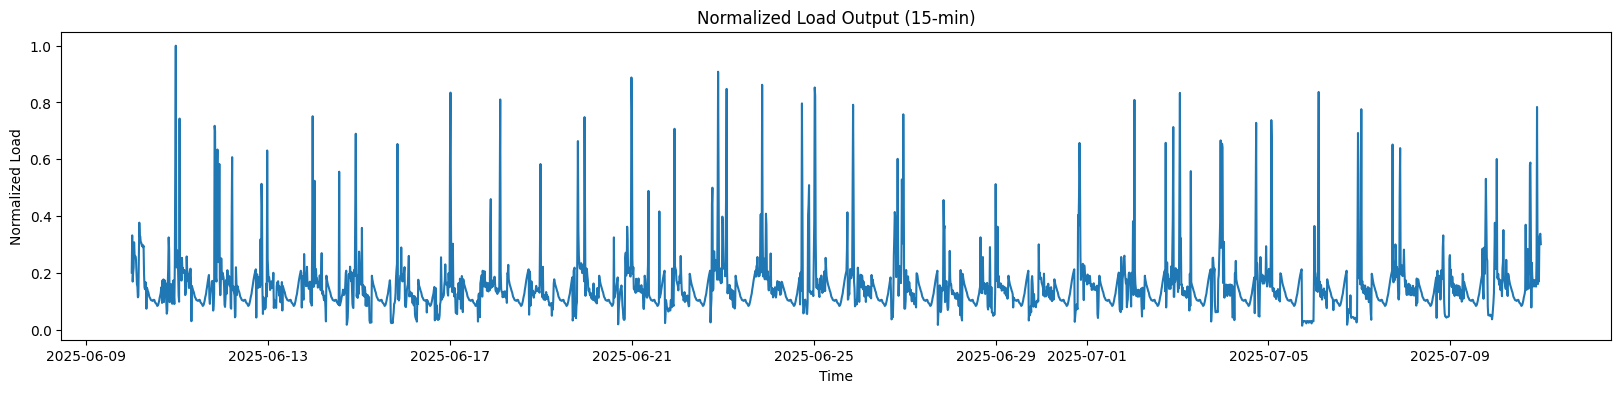

In [6]:
plt.figure(figsize=(20,4))
plt.plot(df["timestamp"], df["load_normalize"])
plt.title("Normalized Load Output (15-min)")
plt.xlabel("Time")
plt.ylabel("Normalized Load")
plt.show()

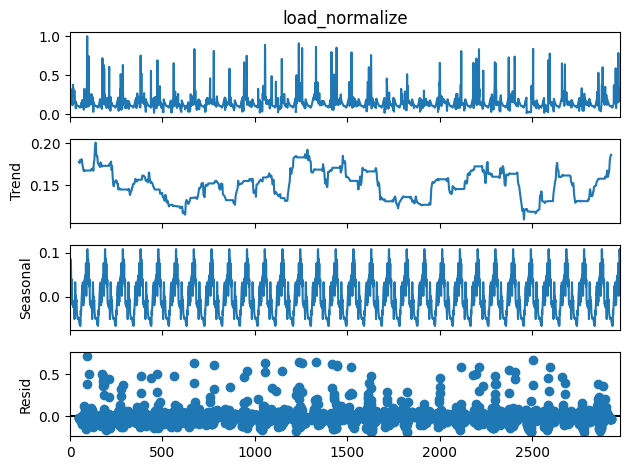

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose
results = seasonal_decompose(df['load_normalize'], model='additive', period=96)  # daily seasonality (96 intervals per day)
results.plot();

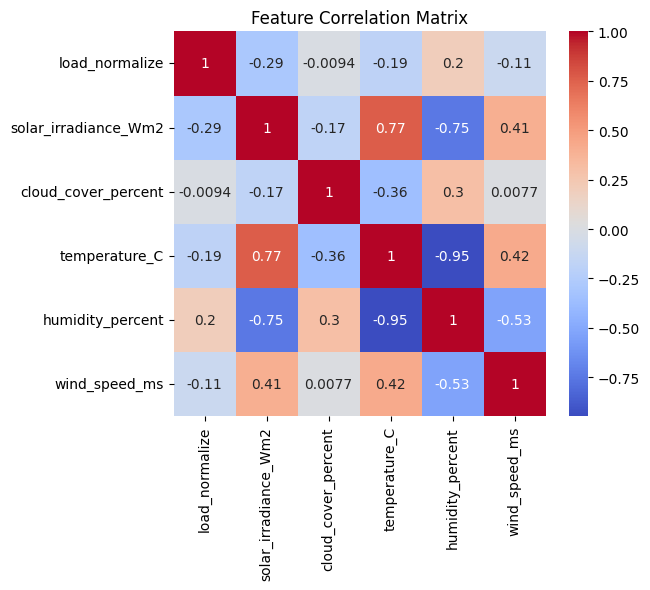

In [8]:
plt.figure(figsize=(6,5))
sns.heatmap(
    df[[
        "load_normalize",
        "solar_irradiance_Wm2",
        "cloud_cover_percent",
        "temperature_C",
        "humidity_percent",
        "wind_speed_ms"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Matrix")
plt.show()

In [9]:
# # Time-based features
# df["hour"] = df["timestamp"].dt.hour
# df["minute"] = df["timestamp"].dt.minute
# df["dayofyear"] = df["timestamp"].dt.dayofyear

# # Solar power lags
# df["solar_lag_1"] = df["solar_normalize"].shift(1)
# df["solar_lag_2"] = df["solar_normalize"].shift(2)
# df["solar_lag_4"] = df["solar_normalize"].shift(4)

# #Drop NaN
# df = df.dropna()

# Ramp rate (intra-hour variability)
#df["solar_ramp"] = df["solar_normalize"] - df["solar_lag_1"]

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2977 entries, 0 to 2976
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             2977 non-null   datetime64[ns]
 1   temperature_C         2977 non-null   float64       
 2   humidity_percent      2977 non-null   float64       
 3   cloud_cover_percent   2977 non-null   float64       
 4   solar_irradiance_Wm2  2977 non-null   float64       
 5   wind_speed_ms         2977 non-null   float64       
 6   load_normalize        2977 non-null   float64       
 7   Unnamed: 7            0 non-null      float64       
 8   Unnamed: 8            0 non-null      float64       
 9   Unnamed: 9            0 non-null      float64       
 10  Unnamed: 10           0 non-null      float64       
 11  Unnamed: 11           0 non-null      float64       
 12  Unnamed: 12           0 non-null      float64       
 13  Unnamed: 13       

In [11]:
features = [
    "load_normalize",
    "humidity_percent",
]

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(df[features])

In [13]:
import numpy as np

n_input = 96   # past 24h
n_output = 96  # future 24h

X = []
y = []

for i in range(0, len(data_scaled) - n_input - n_output, 96):
    X.append(data_scaled[i:i+n_input])
    y.append(data_scaled[i+n_input:i+n_input+n_output, 0])  # only solar

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30, 96, 2)
y shape: (30, 96)


In [14]:
len(X), len(y)

(30, 30)

In [15]:
train_size = int(0.7 * len(X))
val_size   = int(0.15 * len(X))

X_train = X[:train_size]
X_val   = X[train_size:train_size+val_size]
X_test  = X[train_size+val_size:]

y_train = y[:train_size]
y_val   = y[train_size:train_size+val_size]
y_test  = y[train_size+val_size:]

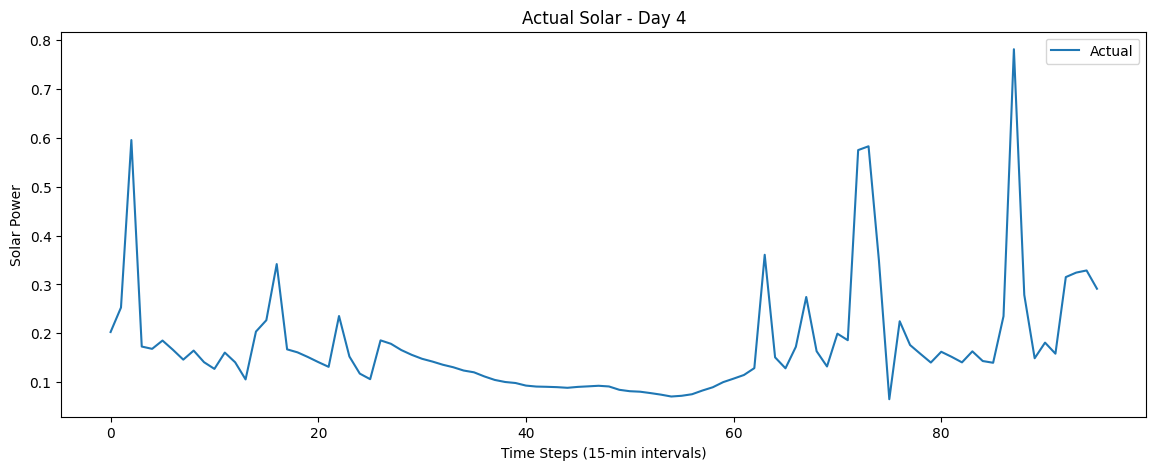

In [17]:
import matplotlib.pyplot as plt

day = 4  # change this to see different days

plt.figure(figsize=(14,5))

plt.plot(y_test[day], label="Actual")

plt.title(f"Actual Solar - Day {day}")
plt.xlabel("Time Steps (15-min intervals)")
plt.ylabel("Solar Power")
plt.legend()

plt.show()

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

# First LSTM layer
model.add(LSTM(128, return_sequences=True, input_shape=(96, X.shape[2])))
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(64))
model.add(Dropout(0.2))

# Output layer (96 steps)
model.add(Dense(96, activation="relu"))  # relu avoids negative values

model.compile(
    optimizer='adam',
    loss='huber'   # better than MSE for peaks
)

model.summary()

c:\Users\HP\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 96, 128)        │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │         6,240 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,720 (479.38 KB)

 Trainable params: 122,720 (479.38 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.0043 - val_loss: 0.0071
Epoch 2/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0042 - val_loss: 0.0071
Epoch 3/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0043 - val_loss: 0.0071
Epoch 4/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0043 - val_loss: 0.0070
Epoch 5/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0041 - val_loss: 0.0069
Epoch 6/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.0042 - val_loss: 0.0069
Epoch 7/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.0042 - val_loss: 0.0070
Epoch 8/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0042 - val_loss: 0.0073
Epoch 9/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 0.0042 - val_loss: 0.0072
Epoch 10/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 0.0041 - val_loss: 0.0070
Epoch 11/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 0.0042 - val_loss: 0.0069
Epoch 12/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - loss: 0.0

In [33]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [34]:
# Create dummy arrays
y_pred_full = np.zeros((y_pred.shape[0], y_pred.shape[1], len(features)))
y_test_full = np.zeros_like(y_pred_full)

# Put solar values back (column 0)
y_pred_full[:,:,0] = y_pred
y_test_full[:,:,0] = y_test

# Inverse transform
y_pred_inv = scaler.inverse_transform(y_pred_full.reshape(-1, len(features)))[:,0]
y_test_inv = scaler.inverse_transform(y_test_full.reshape(-1, len(features)))[:,0]

# Reshape back
y_pred_inv = y_pred_inv.reshape(y_pred.shape)
y_test_inv = y_test_inv.reshape(y_test.shape)

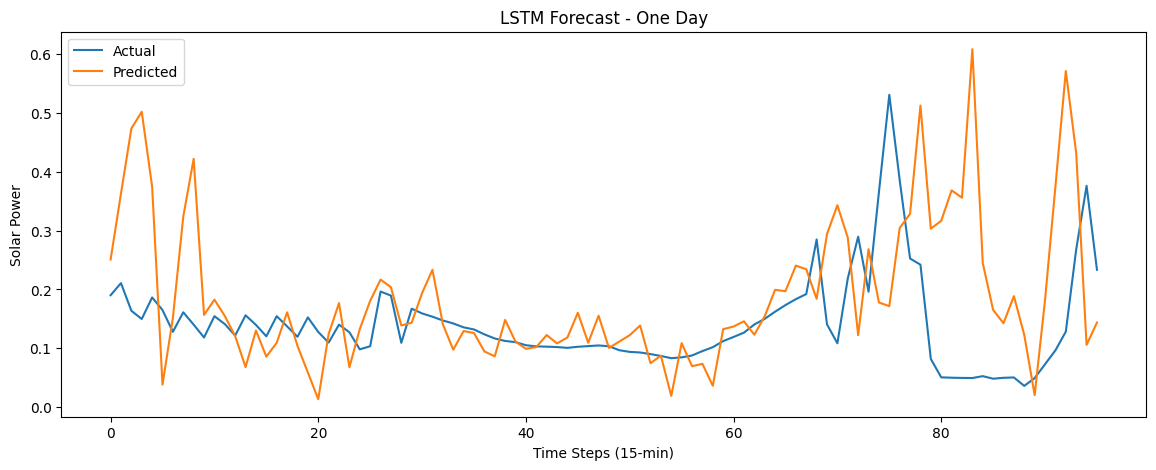

In [41]:
import matplotlib.pyplot as plt

day = 3

plt.figure(figsize=(14,5))

plt.plot(y_test_inv[day], label="Actual")
plt.plot(y_pred_inv[day], label="Predicted")

plt.legend()
plt.title("LSTM Forecast - One Day")
plt.xlabel("Time Steps (15-min)")
plt.ylabel("Solar Power")

plt.show()

In [38]:
from sklearn.metrics import mean_absolute_error, r2_score

y_test_flat = y_test_inv.reshape(-1)
y_pred_flat = y_pred_inv.reshape(-1)

mae = mean_absolute_error(y_test_flat, y_pred_flat)
rmse = np.sqrt(np.mean((y_test_flat - y_pred_flat)**2))
r2 = r2_score(y_test_flat, y_pred_flat)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.09092931989718234
RMSE: 0.15556054345026557
R2: -1.3153820069688593
